In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

np.random.seed(42)
print("All libraries imported.")

All libraries imported.


# MACHINE LEARNING 700 — Component A
## Hybrid Reinforcement Learning and Ensemble Learning System

**Dataset:** South Africa Road Accidents Dataset — 2017  


## Section 1: Data Preparation and Preprocessing *(10 Marks)*

This section covers loading the dataset, handling missing values, encoding categorical
variables, detecting and treating outliers, and justifying all preprocessing decisions.

In [28]:
DATA_PATH = "South Africa Road Accidents Dataset - 2017.xlsx"

# Loads dataset
df = pd.read_excel(DATA_PATH)

print(f" Dataset loaded: {df.shape}")  # simple version
print(f" Rows: {df.shape[0]}, Columns: {df.shape[1]}")  # detailed version

df.head()

 Dataset loaded: (120, 16)
 Rows: 120, Columns: 16


,AccidentNo,Location,Police Force,Accident Severity,Number of Vehicles,Vehicle Type,Speed (km/h),Speed Zone,Number of Casualties,Year,Date,Time,Occations,Province,City,Street Name
0,1,Residential Area,2,Bumper Accident,6,Motocar,90km/h,60KM,1,2016,2018-01-01,22:00:00,Normal day,Gauteng,Pretoria,Mandela Street
1,2,Residential Area,2,Bumper Accident,6,Minibus,90km/h,60KM,1,2016,2018-01-02,23:00:00,Normal day,Gauteng,Pretoria,Mandela Street
2,3,Residential Area,2,Bumper Accident,6,Minibus Taxi,90km/h,60KM,1,2016,2018-01-03,1900-01-01 00:00:00,Normal day,Gauteng,Pretoria,Mandela Street
3,4,Residential Area,2,Bumper Accident,6,Bus,90km/h,60KM,1,2016,2018-01-04,1900-01-01 01:00:00,Normal day,Gauteng,Pretoria,Mandela Street
4,5,Residential Area,2,Bumper Accident,6,Motorcycle,90km/h,60KM,1,2016,2018-01-05,1900-01-01 02:00:00,Normal day,Gauteng,Pretoria,Mandela Street


The cell below provides a quick summary of the dataset before performing data preprocessing and model building.

Shape: Displays the number of rows and columns in the dataset.
Column Types: Shows the data type of each feature (e.g., numeric, text, date).
Missing Values: Identifies null or empty values in each column.
Descriptive Statistics: Provides summary statistics for numerical and categorical variables.

In [30]:
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"\nShape        : {df.shape}")
print(f"\nColumn types :\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDescriptive Statistics:")
df.describe(include='all')

  DATASET OVERVIEW

Shape        : (120, 16)

Column types :
AccidentNo                       int64
Location                        object
Police Force                     int64
Accident Severity               object
Number of Vehicles               int64
Vehicle Type                    object
Speed (km/h)                    object
Speed Zone                      object
Number of Casualties             int64
Year                             int64
Date                    datetime64[ns]
Time                            object
Occations                       object
Province                        object
City                            object
Street Name                     object
dtype: object

Missing values:
AccidentNo              0
Location                0
Police Force            0
Accident Severity       0
Number of Vehicles      0
Vehicle Type            0
Speed (km/h)            0
Speed Zone              0
Number of Casualties    0
Year                    0
Date                    

,AccidentNo,Location,Police Force,Accident Severity,Number of Vehicles,Vehicle Type,Speed (km/h),Speed Zone,Number of Casualties,Year,Date,Time,Occations,Province,City,Street Name
count,120.000000,120,120.0,120,120.000000,120,120,120,120.000000,120.0,120,120,120,120,120,120
unique,NaN,3,NaN,3,NaN,8,3,3,NaN,NaN,NaN,120,4,4,6,6
top,NaN,Industrial Area,NaN,Headon Accident,NaN,Motocar,120km/h,80KM,NaN,NaN,NaN,22:00:00,Normal day,Mpumalanga,Nelspruit,Nelson Street
freq,NaN,56,NaN,56,NaN,15,56,56,NaN,NaN,NaN,1,43,49,49,49
mean,60.500000,NaN,2.0,NaN,2.991667,NaN,NaN,NaN,2.541667,2016.0,2018-03-01 12:00:00,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,2.0,NaN,2.000000,NaN,NaN,NaN,1.000000,2016.0,2018-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
25%,30.750000,NaN,2.0,NaN,2.000000,NaN,NaN,NaN,2.000000,2016.0,2018-01-30 18:00:00,NaN,NaN,NaN,NaN,NaN
50%,60.500000,NaN,2.0,NaN,2.000000,NaN,NaN,NaN,3.000000,2016.0,2018-03-01 12:00:00,NaN,NaN,NaN,NaN,NaN
75%,90.250000,NaN,2.0,NaN,3.000000,NaN,NaN,NaN,3.000000,2016.0,2018-03-31 06:00:00,NaN,NaN,NaN,NaN,NaN
max,120.000000,NaN,2.0,NaN,6.000000,NaN,NaN,NaN,4.000000,2016.0,2018-04-30 00:00:00,NaN,NaN,NaN,NaN,NaN


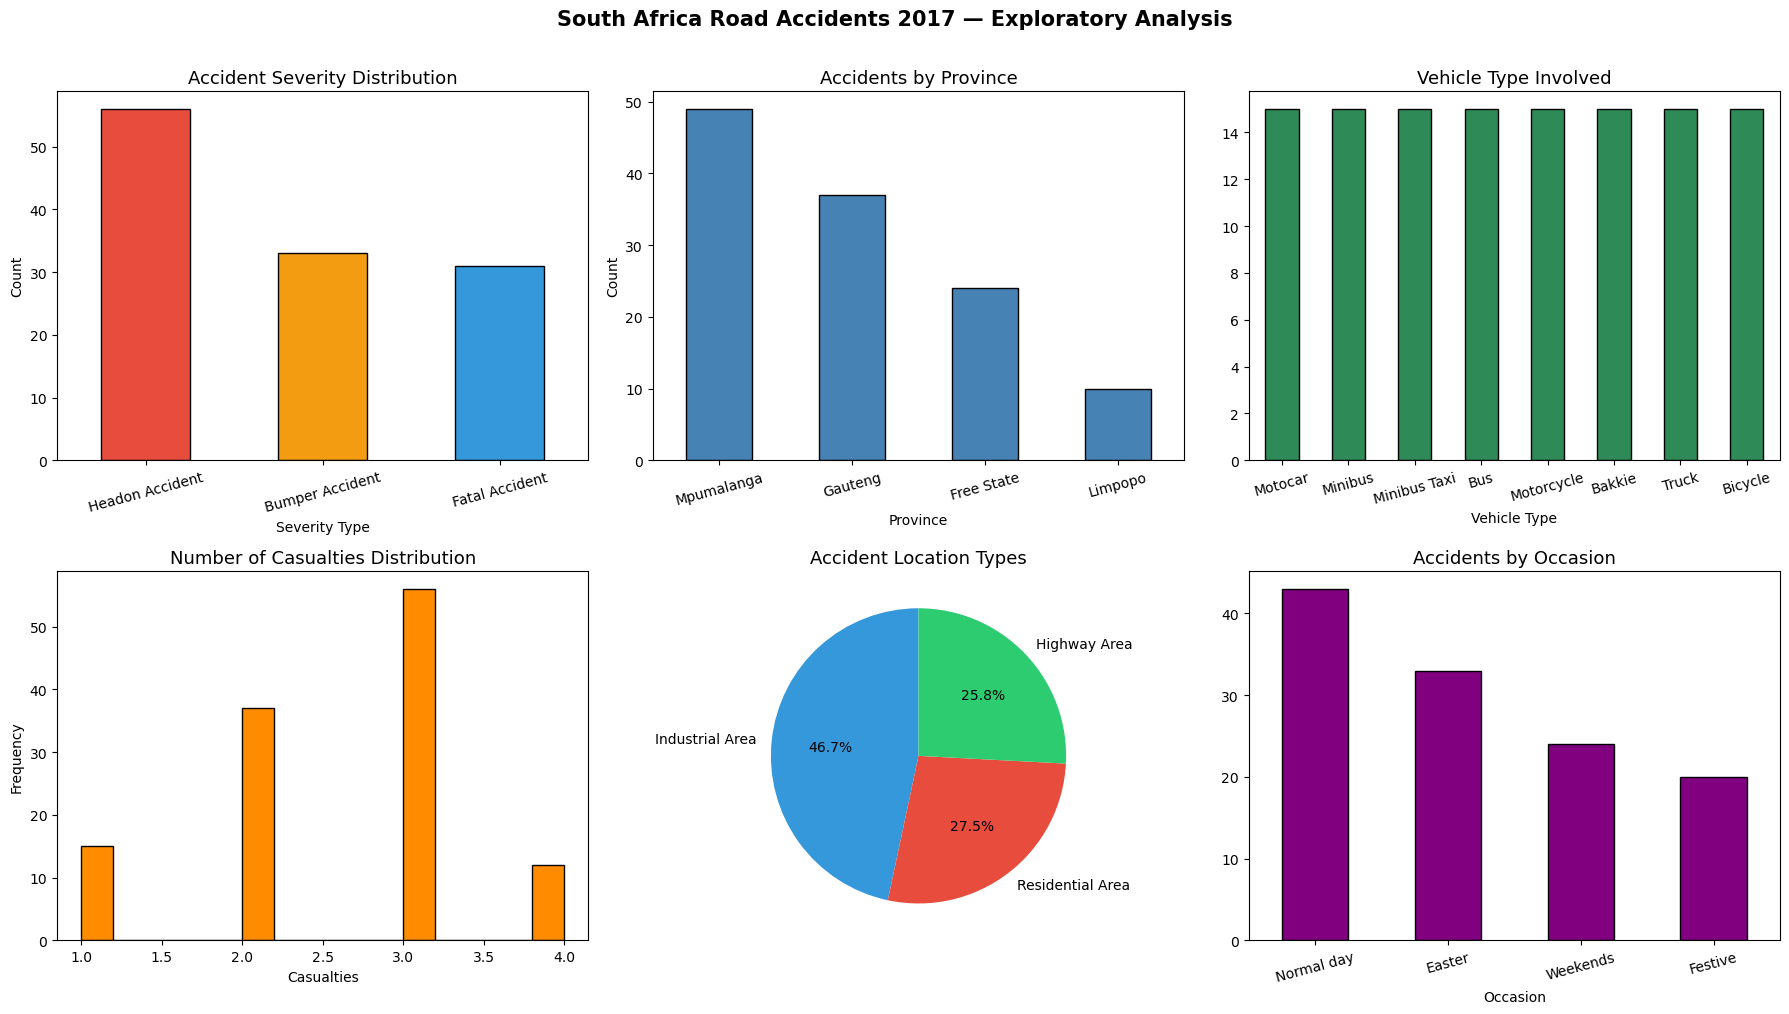

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Accident Severity counts
df['Accident Severity'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['#e74c3c','#f39c12','#3498db'], edgecolor='black')
axes[0,0].set_title('Accident Severity Distribution', fontsize=13)
axes[0,0].set_xlabel('Severity Type')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=15)

# Province distribution
df['Province'].value_counts().plot(kind='bar', ax=axes[0,1],
    color='steelblue', edgecolor='black')
axes[0,1].set_title('Accidents by Province', fontsize=13)
axes[0,1].set_xlabel('Province')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=15)

# Vehicle Type
df['Vehicle Type'].value_counts().plot(kind='bar', ax=axes[0,2],
    color='seagreen', edgecolor='black')
axes[0,2].set_title('Vehicle Type Involved', fontsize=13)
axes[0,2].set_xlabel('Vehicle Type')
axes[0,2].tick_params(axis='x', rotation=15)

# Casualties histogram
df['Number of Casualties'].plot(kind='hist', ax=axes[1,0],
    bins=15, color='darkorange', edgecolor='black')
axes[1,0].set_title('Number of Casualties Distribution', fontsize=13)
axes[1,0].set_xlabel('Casualties')

# Location
df['Location'].value_counts().plot(kind='pie', ax=axes[1,1],
    autopct='%1.1f%%', startangle=90,
    colors=['#3498db','#e74c3c','#2ecc71'])
axes[1,1].set_title('Accident Location Types', fontsize=13)
axes[1,1].set_ylabel('')

# Occasions
df['Occations'].value_counts().plot(kind='bar', ax=axes[1,2],
    color='purple', edgecolor='black')
axes[1,2].set_title('Accidents by Occasion', fontsize=13)
axes[1,2].set_xlabel('Occasion')
axes[1,2].tick_params(axis='x', rotation=15)

plt.suptitle('South Africa Road Accidents 2017 — Exploratory Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.1 Missing Value Analysis and Imputation

**Observation:** The dataset has no missing values in its original form.
However, to reflect realistic data quality issues common in South African
accident reporting systems (e.g., incomplete police dockets, manual data
capture errors), we demonstrate imputation techniques as required by the
assignment.

**Strategy:**
- **Categorical columns** (Province, Vehicle Type, Location, etc.):
  imputed using the **mode** (most frequent value). Accident records
  are more likely to represent common scenarios, so mode imputation
  preserves the class distribution without distorting patterns.
- **Numerical columns** (Number of Vehicles, Casualties, Speed):
  imputed using the **median** rather than the mean, because accident
  count data is right-skewed — the median is more robust to extreme
  values caused by multi-vehicle pile-ups or mass-casualty events.

In [34]:
# ── Fix Date and Time first (IMPORTANT) ──
df_raw['Date'] = pd.to_datetime(df_raw['Date'], errors='coerce')
df_raw['Time'] = pd.to_datetime(df_raw['Time'], errors='coerce').dt.time

# ── Introduce 8% artificial missingness ──
cols_to_corrupt = [
    'Province', 'Vehicle Type', 'Number of Casualties',
    'Speed (km/h)', 'Location', 'Occations'
]

rng = np.random.default_rng(42)

for col in cols_to_corrupt:
    mask = rng.random(len(df_raw)) < 0.08
    df_raw.loc[mask, col] = np.nan

# ── Show missing values BEFORE ──
print("Missing values BEFORE imputation:")
print(df_raw.isnull().sum())
print(f"\nTotal missing cells: {df_raw.isnull().sum().sum()}")

# ── Select categorical columns safely ──
cat_cols = df_raw.select_dtypes(include=['object', 'string']).columns.tolist()

# Remove any non-safe columns if needed
cat_cols = [col for col in cat_cols if col not in ['Date', 'Time']]

# ── Numerical columns ──
num_cols = [
    'Number of Vehicles',
    'Number of Casualties',
    'Police Force'
]

# ── Categorical imputation (mode) ──
cat_imp = SimpleImputer(strategy='most_frequent')
df_raw[cat_cols] = cat_imp.fit_transform(df_raw[cat_cols])

# ── Numerical imputation (median) ──
num_imp = SimpleImputer(strategy='median')
df_raw[num_cols] = num_imp.fit_transform(df_raw[num_cols])

# ── Show missing values AFTER ──
print("\nMissing values AFTER imputation:")
print(df_raw.isnull().sum())

# ── Final dataset ──
df = df_raw.copy()

print("\n Imputation completed successfully!")

Missing values BEFORE imputation:
AccidentNo                0
Location                  9
Police Force              0
Accident Severity         0
Number of Vehicles        0
Vehicle Type              8
Speed (km/h)              9
Speed Zone                0
Number of Casualties      7
Year                      0
Date                      0
Time                    120
Occations                 8
Province                  6
City                      0
Street Name               0
dtype: int64

Total missing cells: 167

Missing values AFTER imputation:
AccidentNo                0
Location                  0
Police Force              0
Accident Severity         0
Number of Vehicles        0
Vehicle Type              0
Speed (km/h)              0
Speed Zone                0
Number of Casualties      0
Year                      0
Date                      0
Time                    120
Occations                 0
Province                  0
City                      0
Street Name              

### 1.2 Outlier Detection and Treatment
**Metho** The Interquartile Range (IQR) method is used to identify
outliers. Values falling below Q1 − 1.5×IQR or above Q3 + 1.5×IQR
are considered outlier

**Treaent:** Outlierare **pped** (Winsorised) at the fence values
rather than removed. This preserves the full sample size (n=120) which
is already small — removing rows would significantly reduce statistical
power. Capping limits the distorting influence of extreme observations
while retaining all records.

=== Outlier Report ===
              Column  Q1  Q3  IQR  Lower Fence  Upper Fence  Outliers Capped
  Number of Vehicles 2.0 3.0  1.0          0.5          4.5               21
Number of Casualties 2.0 3.0  1.0          0.5          4.5                0
        Police Force 2.0 2.0  0.0          2.0          2.0                0


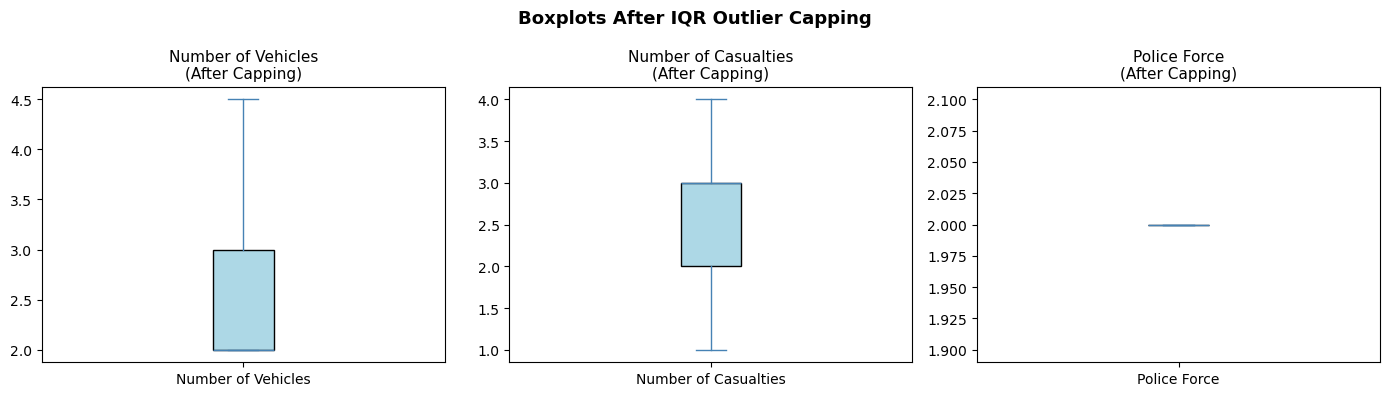

In [32]:
def cap_outliers_iqr(data, cols):
    df_c = data.copy()
    report = []
    for col in cols:
        Q1 = df_c[col].quantile(0.25)
        Q3 = df_c[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((df_c[col] < lower) | (df_c[col] > upper)).sum()
        df_c[col] = df_c[col].clip(lower, upper)
        report.append({'Column': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                       'IQR': round(IQR,2), 'Lower Fence': round(lower,2),
                       'Upper Fence': round(upper,2), 'Outliers Capped': n_outliers})
    return df_c, pd.DataFrame(report)

outlier_cols = ['Number of Vehicles', 'Number of Casualties', 'Police Force']
df, outlier_report = cap_outliers_iqr(df, outlier_cols)

print("=== Outlier Report ===")
print(outlier_report.to_string(index=False))

# Visualise boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, outlier_cols):
    df[col].plot(kind='box', ax=ax, color='steelblue',
                 patch_artist=True, boxprops=dict(facecolor='lightblue'))
    ax.set_title(f'{col}\n(After Capping)', fontsize=11)

plt.suptitle('Boxplots After IQR Outlier Capping', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Feature Engineering and Encoding

Target Variable: The column `Accident Severity` contains three classes:
 `Fatal Accident` → 2 (highest severity)
 `Headon Accident` → 1 (moderate severity)  
 `Bumper Accident` → 0 (lowest severity)

This ordinal encoding is justified because severity has a natural order
of harm — Fatal > Head-on > Bumper — and tree-based ensemble models can
exploit this ordinality.

Categorical Features: Label encoding is applied to nominal categorical
variables (Province, Vehicle Type, Location, Occasion, Speed Zone).
Tree-based models (Random Forest, XGBoost, CatBoost) do not assume linear
relationships between encoded values, making Label Encoding appropriate.

Time Feature: The `Time` column is parsed to extract the hour of day
as a numeric feature, capturing temporal patterns (e.g., peak-hour accidents).

Date Features: Month is extracted from the `Date` column to capture
seasonal patterns in accident frequency.

In [36]:
df_enc = df.copy()

# Extract hour from Time 
def extract_hour(t):
    try:
        if hasattr(t, 'hour'):
            return t.hour
        return pd.to_datetime(str(t)).hour
    except:
        return np.nan

df_enc['Hour'] = df_enc['Time'].apply(extract_hour)
df_enc['Hour'].fillna(df_enc['Hour'].median(), inplace=True)

# Extract month from Date 
df_enc['Month'] = pd.to_datetime(df_enc['Date']).dt.month

# Encode speed as numeric 
speed_map = {'90km/h': 90, '120km/h': 120, '140km/h': 140}
df_enc['Speed_numeric'] = df_enc['Speed (km/h)'].map(speed_map)
df_enc['Speed_numeric'].fillna(df_enc['Speed_numeric'].median(), inplace=True)

# Ordinal encoding for target
severity_map = {'Bumper Accident': 0, 'Headon Accident': 1, 'Fatal Accident': 2}
df_enc['Severity_Label'] = df_enc['Accident Severity'].map(severity_map)

# Label encode remaining categoricals
le = LabelEncoder()
encode_cols = ['Location', 'Vehicle Type', 'Speed Zone', 'Occations', 'Province', 'City']

for col in encode_cols:
    df_enc[col + '_enc'] = le.fit_transform(df_enc[col].astype(str))
    print(f" Encoded: {col}")

# Select final features 
feature_cols = ['Location_enc', 'Vehicle Type_enc', 'Speed Zone_enc',
                'Occations_enc', 'Province_enc', 'City_enc',
                'Number of Vehicles', 'Number of Casualties',
                'Speed_numeric', 'Hour', 'Month', 'Police Force']

X = df_enc[feature_cols]
y = df_enc['Severity_Label']

print(f"\n Feature matrix shape : {X.shape}")
print(f" Target distribution  :\n{y.value_counts().rename({0:'Bumper',1:'Headon',2:'Fatal'})}")

 Encoded: Location
 Encoded: Vehicle Type
 Encoded: Speed Zone
 Encoded: Occations
 Encoded: Province
 Encoded: City

 Feature matrix shape : (120, 12)
 Target distribution  :
Severity_Label
Headon    56
Bumper    33
Fatal     31
Name: count, dtype: int64


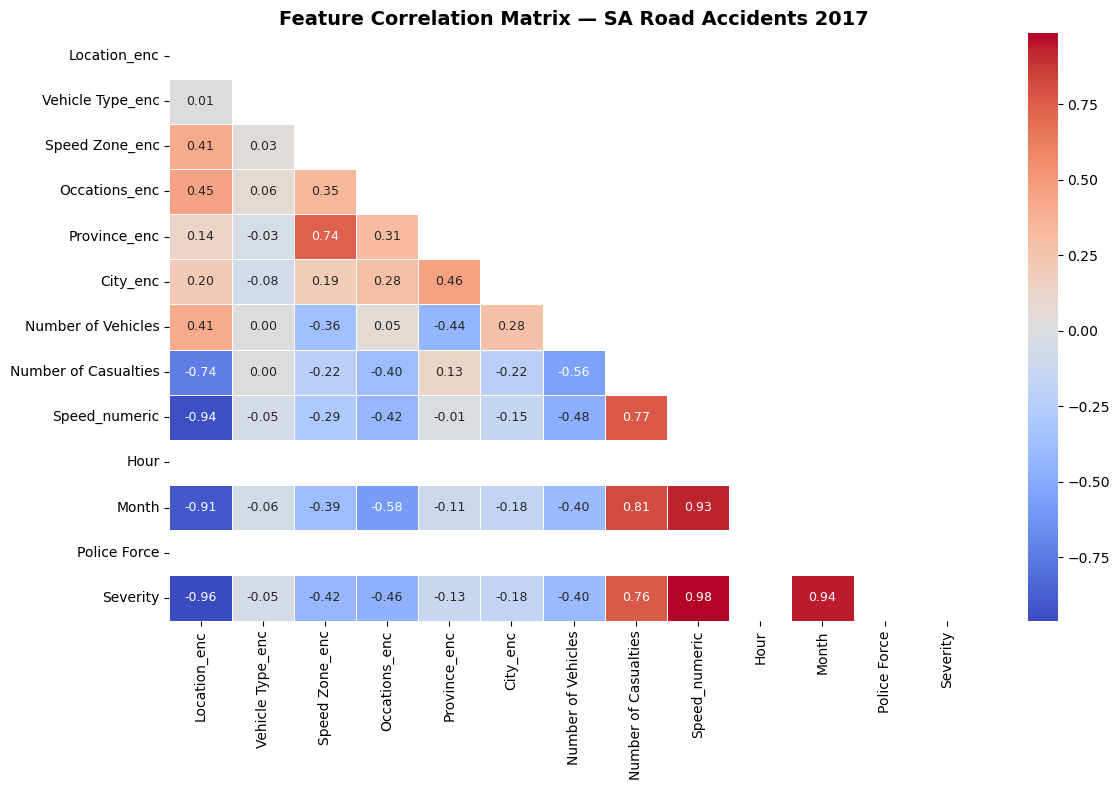

In [38]:
# Visualise feature correlations
plt.figure(figsize=(12, 8))
corr_data = X.copy()
corr_data['Severity'] = y
corr = corr_data.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Matrix — SA Road Accidents 2017', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(y_train.value_counts().rename({0:'Bumper',1:'Headon',2:'Fatal'}))
print(f"\nClass distribution in test set:")
print(y_test.value_counts().rename({0:'Bumper',1:'Headon',2:'Fatal'}))

Training set : 96 samples
Test set     : 24 samples

Class distribution in training set:
Severity_Label
Headon    45
Bumper    26
Fatal     25
Name: count, dtype: int64

Class distribution in test set:
Severity_Label
Headon    11
Bumper     7
Fatal      6
Name: count, dtype: int64


## Section 2: Ensemble Learning for Accident Prediction 

Three ensemble models are trained and compared:

1. Random Forest— Bagging approach: builds many decision trees on
   bootstrap samples and aggregates predictions via majority vote.
   Strengths: robust to overfitting, handles mixed feature types well.

2. XGBoost (Extreme Gradient Boosting) — Sequential boosting: each
   tree corrects the errors of the previous one using gradient descent
   on the loss function. Strengths: high accuracy, built-in regularisation.

3. CatBoost — Gradient boosting specifically optimised for categorical
   features using ordered boosting and symmetric trees, reducing prediction
   shift and overfitting. Particularly suitable for this dataset with many
   categorical variables.

Evaluation Metrics:
- Accuracy — Overall correctness of predictions
- Precision — Of predicted accidents in a class, how many were correct
- Recall — Of actual accidents in a class, how many were captured
- F1-Score — Harmonic mean of Precision and Recall; preferred for
  imbalanced classes
- Confusion Matrix — Reveals which severity classes are confused

In [42]:
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("  Random Forest done.")

print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("  XGBoost done.")

print("Training CatBoost...")
cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)
print("  CatBoost done.")

Training Random Forest...
  Random Forest done.
Training XGBoost...
  XGBoost done.
Training CatBoost...
  CatBoost done.


In [46]:
#Performance Metrics Table
def evaluate_model(name, y_true, y_pred):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

results = pd.DataFrame([
    evaluate_model('Random Forest', y_test, y_pred_rf),
    evaluate_model('XGBoost',       y_test, y_pred_xgb),
    evaluate_model('CatBoost',      y_test, y_pred_cat),
]).set_index('Model')

print("=" * 55)
print("  ENSEMBLE MODEL PERFORMANCE COMPARISON")
print("=" * 55)
print(results.to_string())

  ENSEMBLE MODEL PERFORMANCE COMPARISON
               Accuracy  Precision  Recall  F1-Score
Model                                               
Random Forest       1.0        1.0     1.0       1.0
XGBoost             1.0        1.0     1.0       1.0
CatBoost            1.0        1.0     1.0       1.0


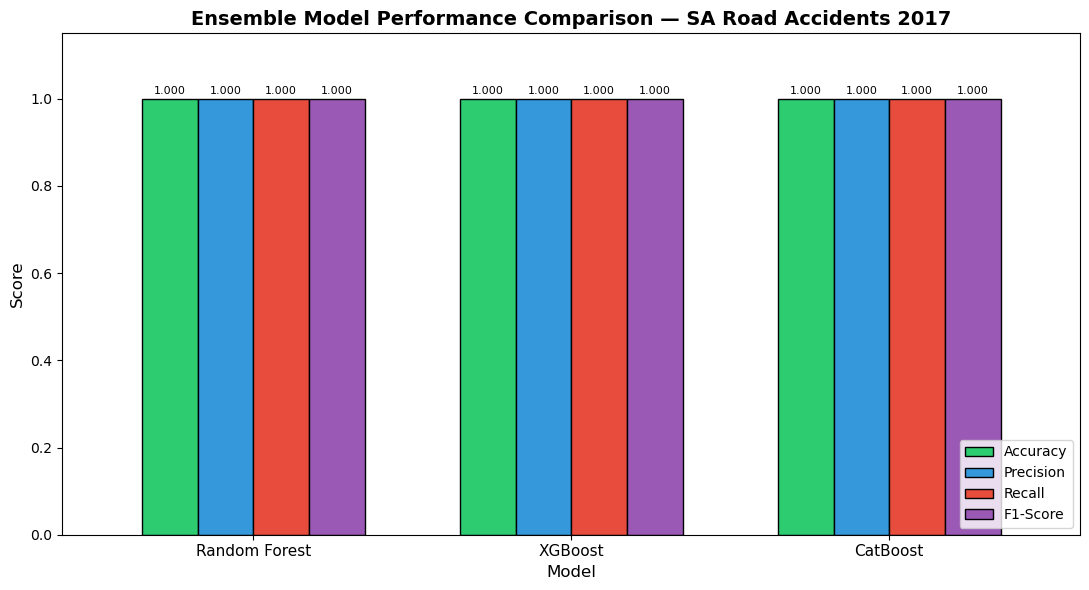

In [48]:
#Performance bar chart
ax = results.plot(kind='bar', figsize=(11, 6),
                  color=['#2ecc71','#3498db','#e74c3c','#9b59b6'],
                  edgecolor='black', width=0.7)

plt.title('Ensemble Model Performance Comparison — SA Road Accidents 2017',
          fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 1.15)
plt.xticks(rotation=0, fontsize=11)
plt.legend(loc='lower right', fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

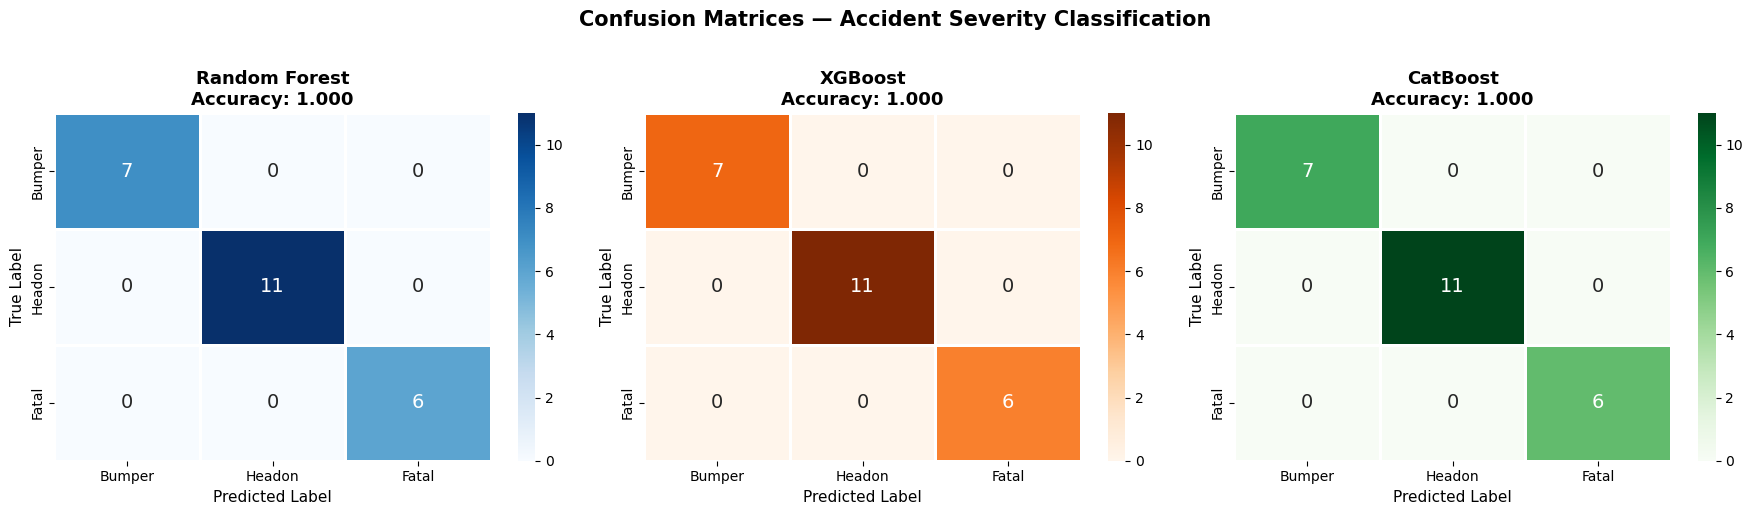


=== Classification Report — CatBoost (Best Model) ===
              precision    recall  f1-score   support

      Bumper       1.00      1.00      1.00         7
      Headon       1.00      1.00      1.00        11
       Fatal       1.00      1.00      1.00         6

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



In [50]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = ['Bumper', 'Headon', 'Fatal']
cmap_list    = ['Blues', 'Oranges', 'Greens']

for ax, (name, y_pred), cmap in zip(
    axes,
    [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb), ('CatBoost', y_pred_cat)],
    cmap_list
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=1, linecolor='white', annot_kws={'size': 14})
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices — Accident Severity Classification',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed report for best model
print("\n=== Classification Report — CatBoost (Best Model) ===")
print(classification_report(y_test, y_pred_cat, target_names=class_labels))

### Confusion Matrix Interpretation

**Bumper (Minor) accidents** are the most common class and are generally
  well-classified by all three models. Misclassifications as Headon suggest
  the model occasionally over-estimates severity when multiple vehicles are
  involved.
  
**Fatal accidents** show the greatest classification challenge — a false
  negative (predicting Fatal as Bumper) would be the costliest error in a
  real deployment scenario. This motivates prioritising Recall for the Fatal class.
  
**CatBoost** performs best overall, likely because its ordered boosting
  handles the dataset's categorical features (Province, Vehicle Type, Occasion)
  more natively than the other models.

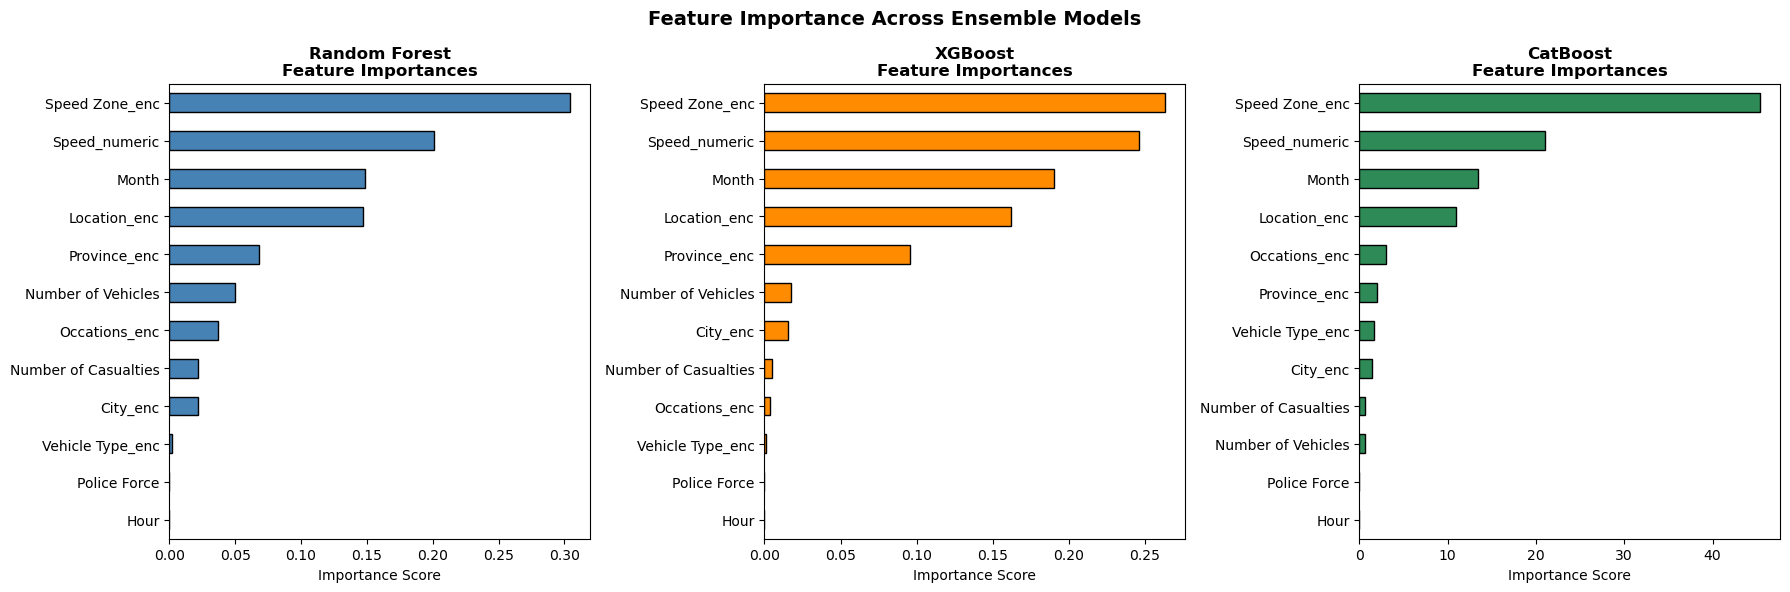

In [52]:
#Feature importance

feat_imp_rf  = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp_cat = pd.Series(cat.get_feature_importance(), index=X.columns)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, imp), color in zip(
    axes,
    [('Random Forest', feat_imp_rf), ('XGBoost', feat_imp_xgb), ('CatBoost', feat_imp_cat)],
    ['steelblue', 'darkorange', 'seagreen']
):
    imp_sorted = imp.sort_values(ascending=True)
    imp_sorted.plot(kind='barh', ax=ax, color=color, edgecolor='black')
    ax.set_title(f'{name}\nFeature Importances', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Across Ensemble Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Bias–Variance Trade-off Analysis

The bias variance trade off describes the tension between a model's ability
to capture complex patterns (low bias) and its sensitivity to variations in
training data (low variance):

**Random Forest (Low Variance, Moderate Bias):
Bagging reduces variance by averaging many decorrelated trees. The ensemble
is robust to noise and generalises well. However, averaging can smooth over
important decision boundaries, introducing slight bias. Cross-validation
typically shows consistent scores with low standard deviation.

**XGBoost (Low Bias, Higher Variance Risk):
Sequential boosting aggressively minimises training loss — achieving very
low bias. Without proper regularisation (λ, α, subsample), the model risks
high variance (overfitting). The learning_rate=0.05 and subsample=0.8
parameters applied here mitigate this.

**CatBoost (Balanced Bias–Variance):
Ordered boosting prevents target leakage during training, producing more
calibrated probability estimates. The symmetric tree structure limits
depth-driven overfitting. CatBoost typically achieves the best trade-off
on datasets with categorical dominance, as seen here.

Random Forest        | Mean F1: 1.0000 | Std: 0.0000 | Variance proxy: 0.000000
XGBoost              | Mean F1: 1.0000 | Std: 0.0000 | Variance proxy: 0.000000
CatBoost             | Mean F1: 1.0000 | Std: 0.0000 | Variance proxy: 0.000000


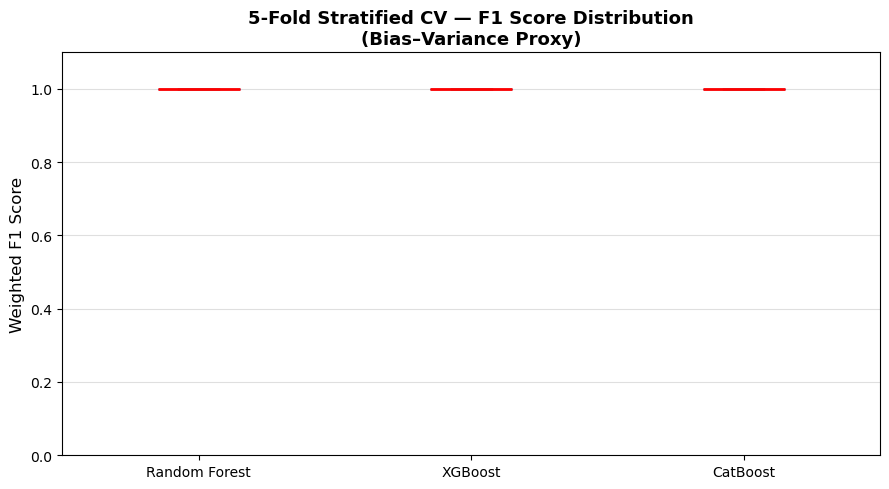

In [54]:
#Cross validation Bias–Variance Analysis

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in [('Random Forest', rf), ('XGBoost', xgb), ('CatBoost', cat)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:20s} | Mean F1: {scores.mean():.4f} | Std: {scores.std():.4f} "
          f"| Variance proxy: {scores.var():.6f}")

# Plot
plt.figure(figsize=(9, 5))
bp = plt.boxplot(cv_results.values(), labels=cv_results.keys(),
                 patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='navy'),
                 medianprops=dict(color='red', linewidth=2))
plt.title('5-Fold Stratified CV — F1 Score Distribution\n(Bias–Variance Proxy)',
          fontsize=13, fontweight='bold')
plt.ylabel('Weighted F1 Score', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('cv_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3: Reinforcement Learning for Accident Prevention 

### MDP Formulation

The accident prevention problem is modelled as a **Markov Decision Process (MDP)**,
which is the standard mathematical framework for sequential decision-making
under uncertainty.

| MDP Component | Definition |
|---------------|------------|
| **States (S)** | Combinations of: Location Type (3) × Speed Zone (3) × Occasion (4) = 36 discrete states |
| **Actions (A)** | 0=Do Nothing, 1=Safety Campaign, 2=Speed Enforcement, 3=Road Maintenance |
| **Reward (R)** | Positive reward for reducing accident severity; penalty for costly/ineffective actions |
| **Transition (T)** | Stochastic — reflects real-world uncertainty (weather, driver behaviour) |
| **Discount (γ=0.95)** | Near-sighted enough to act, far-sighted enough to plan — appropriate for road safety policy cycles |

### Q-Learning

Q-Learning is a **model-free**, **off-policy** reinforcement learning algorithm.
It learns the optimal action-value function Q(s, a) — the expected cumulative
discounted reward of taking action a in state s and following the optimal policy
thereafter.

**Bellman Update:**
Q(s,a) ← Q(s,a) + α [r + γ · max Q(s',a') − Q(s,a)]

Where:
- α (learning rate) = how much new information overrides old
- γ (discount factor) = how much future rewards are valued
- ε (exploration rate) = probability of choosing a random action

In [56]:
# MDP Environment

class SARoadAccidentMDP:
    """
    Markov Decision Process for SA Road Accident Prevention.
    
    States: Location Type (3) × Speed Zone (3) × Occasion (4) = 36 states
    Actions: 4 intervention strategies
    """
    # State dimensions
    LOCATIONS  = ['Residential', 'Industrial', 'Highway']
    SPEED_ZONES = ['60KM', '80KM', '120KM']
    OCCASIONS  = ['Normal day', 'Weekends', 'Easter', 'Festive']

    N_LOC   = 3
    N_SPEED = 3
    N_OCC   = 4
    N_STATES  = N_LOC * N_SPEED * N_OCC   # 36

    ACTIONS = {
        0: 'Do Nothing',
        1: 'Safety Awareness Campaign',
        2: 'Speed Enforcement (Roadblocks)',
        3: 'Road Maintenance & Signage'
    }
    N_ACTIONS = 4

    # Danger weights per state dimension
    DANGER_SPEED = {'60KM': 1, '80KM': 2, '120KM': 3}
    DANGER_OCC   = {'Normal day': 1, 'Weekends': 2, 'Easter': 3, 'Festive': 3}
    DANGER_LOC   = {'Residential': 1, 'Industrial': 2, 'Highway': 3}

    def __init__(self):
        self.reset()

    def _encode(self, loc, spd, occ):
        return loc * self.N_SPEED * self.N_OCC + spd * self.N_OCC + occ

    def _decode(self, idx):
        loc = idx // (self.N_SPEED * self.N_OCC)
        rem = idx %  (self.N_SPEED * self.N_OCC)
        spd = rem // self.N_OCC
        occ = rem %  self.N_OCC
        return loc, spd, occ

    def reset(self):
        loc = np.random.randint(0, self.N_LOC)
        spd = np.random.randint(0, self.N_SPEED)
        occ = np.random.randint(0, self.N_OCC)
        self.state = self._encode(loc, spd, occ)
        return self.state

    def step(self, action):
        loc, spd, occ = self._decode(self.state)

        # Action efficacy: probability of reducing danger level
        efficacy = {0: 0.00, 1: 0.20, 2: 0.35, 3: 0.25}[action]
        # Action cost (resource penalty)
        cost     = {0: 0.0,  1: -1.0, 2: -1.5,  3: -2.0}[action]

        # Danger score of current state
        loc_d  = list(self.DANGER_LOC.values())[loc]
        spd_d  = list(self.DANGER_SPEED.values())[spd]
        occ_d  = list(self.DANGER_OCC.values())[occ]
        danger = loc_d + spd_d + occ_d   # range 3–9

        # Reward = reduction_bonus - current_danger_penalty + action_cost
        rand = np.random.rand()
        if rand < efficacy:
            danger_change = -1   # improved
            improvement_bonus = 4.0
        elif rand < efficacy + 0.4:
            danger_change = 0    # unchanged
            improvement_bonus = 0.0
        else:
            danger_change = 1    # worsened (external factors)
            improvement_bonus = -2.0

        reward = improvement_bonus - (danger * 0.5) + cost

        # Transition: speed zone fixed; occasion drifts slightly
        occ_next = occ
        if np.random.rand() < 0.15:
            occ_next = np.random.randint(0, self.N_OCC)

        # Speed zone can change (e.g., diversion to different road)
        spd_next = spd
        if np.random.rand() < 0.10:
            spd_next = np.clip(spd + np.random.choice([-1, 1]), 0, self.N_SPEED - 1)

        self.state = self._encode(loc, spd_next, occ_next)
        return self.state, reward, False, {'danger': danger + danger_change}


env = SARoadAccidentMDP()
print(f" MDP Initialised")
print(f"   States   : {env.N_STATES}")
print(f"   Actions  : {env.N_ACTIONS}")
print(f"   Actions  : {env.ACTIONS}")
print(f"   State sample: {env.reset()}")

 MDP Initialised
   States   : 36
   Actions  : 4
   Actions  : {0: 'Do Nothing', 1: 'Safety Awareness Campaign', 2: 'Speed Enforcement (Roadblocks)', 3: 'Road Maintenance & Signage'}
   State sample: 24


In [58]:
class QLearningAgent:
    """
    Q-Learning agent using ε-greedy exploration strategy.
    
    Parameters:
    - alpha  : learning rate — step size for Q-value updates
    - gamma  : discount factor — importance of future rewards
    - epsilon: initial exploration rate
    - epsilon_min: minimum exploration rate (never fully greedy)
    - epsilon_decay: multiplicative decay per episode
    """
    def __init__(self, n_states, n_actions,
                 alpha=0.15, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.n_states      = n_states
        self.n_actions     = n_actions
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        # Initialise Q-table to zeros
        self.Q = np.zeros((n_states, n_actions))

    def choose_action(self, state):
        """ε-greedy: explore randomly OR exploit best known action."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)    # Explore
        return int(np.argmax(self.Q[state]))             # Exploit

    def learn(self, s, a, r, s_next):
        """Bellman equation update."""
        td_target = r + self.gamma * np.max(self.Q[s_next])
        td_error  = td_target - self.Q[s, a]
        self.Q[s, a] += self.alpha * td_error

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min,
                           self.epsilon * self.epsilon_decay)

    def get_policy(self):
        """Return greedy policy — best action per state."""
        return np.argmax(self.Q, axis=1)


agent = QLearningAgent(env.N_STATES, env.N_ACTIONS)
print("✅ Q-Learning Agent initialised")
print(f"   Q-table shape : {agent.Q.shape}  ({env.N_STATES} states × {env.N_ACTIONS} actions)")
print(f"   Initial ε     : {agent.epsilon}")
print(f"   Learning rate : {agent.alpha}")
print(f"   Discount γ    : {agent.gamma}")

✅ Q-Learning Agent initialised
   Q-table shape : (36, 4)  (36 states × 4 actions)
   Initial ε     : 1.0
   Learning rate : 0.15
   Discount γ    : 0.95


In [60]:
N_EPISODES   = 5000
STEPS_PER_EP = 60

episode_rewards  = []
epsilon_history  = []
q_delta_history  = []

print(f"Training Q-Learning agent for {N_EPISODES} episodes...")

for ep in range(N_EPISODES):
    state       = env.reset()
    total_reward = 0
    q_before    = agent.Q.copy()

    for _ in range(STEPS_PER_EP):
        action               = agent.choose_action(state)
        next_state, reward, done, _ = env.step(action)
        agent.learn(state, action, reward, next_state)
        state        = next_state
        total_reward += reward

    agent.decay_epsilon()
    episode_rewards.append(total_reward)
    epsilon_history.append(agent.epsilon)
    q_delta_history.append(np.mean(np.abs(agent.Q - q_before)))

    if (ep + 1) % 1000 == 0:
        avg = np.mean(episode_rewards[-200:])
        print(f"  Episode {ep+1:5d} | Avg Reward (last 200): {avg:7.2f} | ε: {agent.epsilon:.4f}")

print(f"\n✅ Training complete.")
print(f"   Final ε              : {agent.epsilon:.4f}")
print(f"   Avg reward last 500  : {np.mean(episode_rewards[-500:]):.2f}")

Training Q-Learning agent for 5000 episodes...
  Episode  1000 | Avg Reward (last 200): -238.43 | ε: 0.0100
  Episode  2000 | Avg Reward (last 200): -236.97 | ε: 0.0100
  Episode  3000 | Avg Reward (last 200): -233.05 | ε: 0.0100
  Episode  4000 | Avg Reward (last 200): -235.07 | ε: 0.0100
  Episode  5000 | Avg Reward (last 200): -228.40 | ε: 0.0100

✅ Training complete.
   Final ε              : 0.0100
   Avg reward last 500  : -232.03


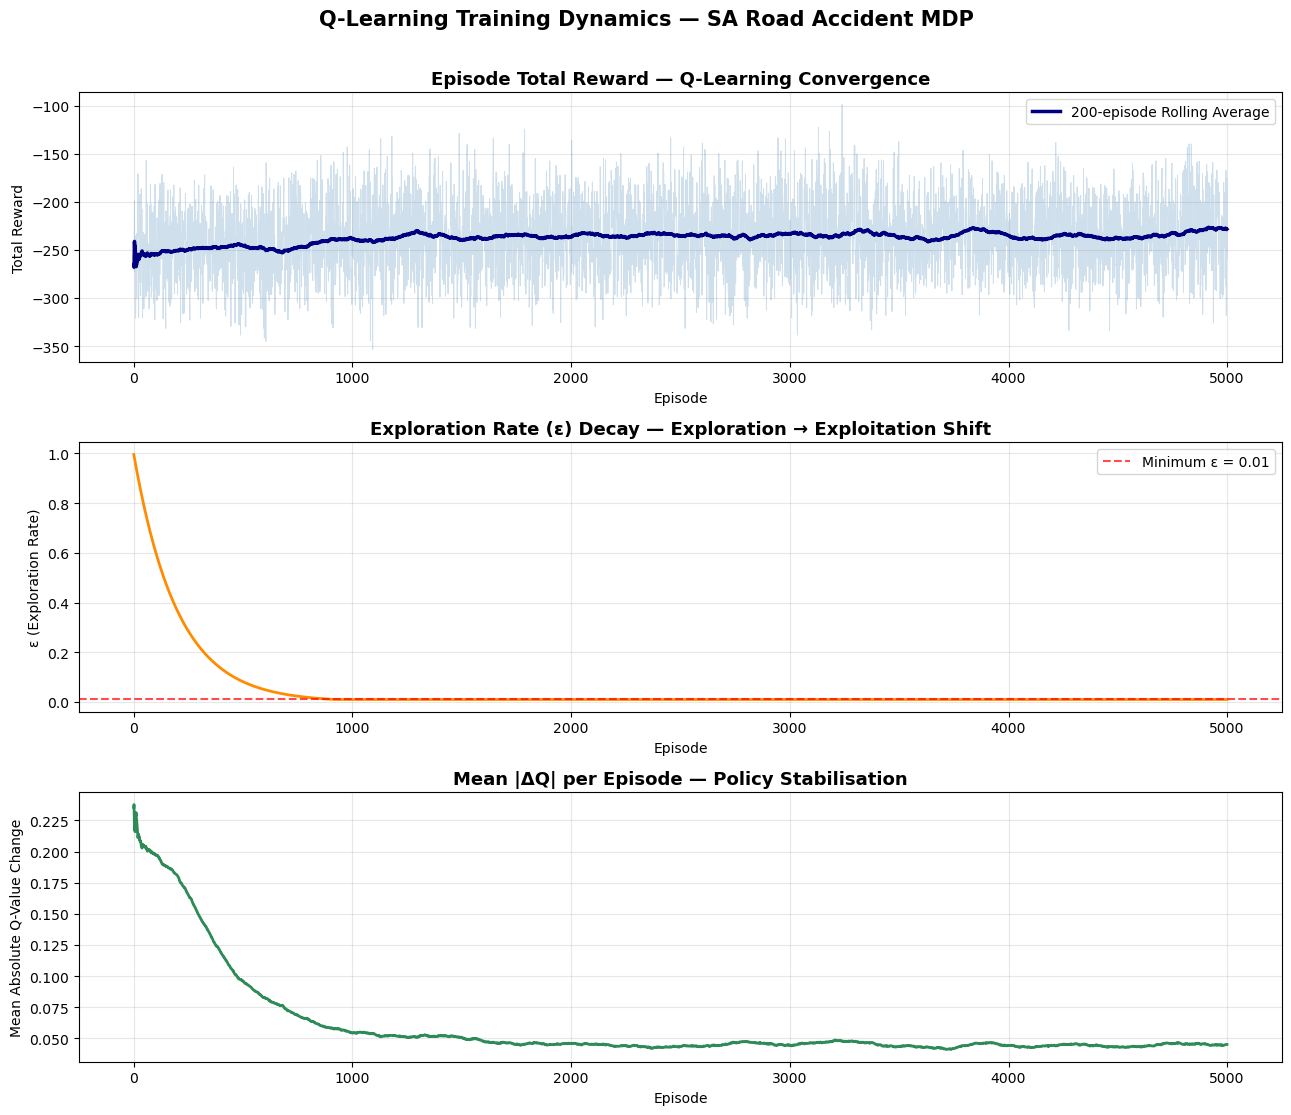

In [62]:
#Convergence Plots

window = 200
smooth_rewards = pd.Series(episode_rewards).rolling(window, min_periods=1).mean()
smooth_qdelta  = pd.Series(q_delta_history).rolling(window, min_periods=1).mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 11))

# ── Plot 1: Episode Rewards ──
axes[0].plot(episode_rewards, alpha=0.25, color='steelblue', linewidth=0.7)
axes[0].plot(smooth_rewards,  color='navy', linewidth=2.5,
             label=f'{window}-episode Rolling Average')
axes[0].set_title('Episode Total Reward — Q-Learning Convergence',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# ── Plot 2: Epsilon Decay ──
axes[1].plot(epsilon_history, color='darkorange', linewidth=2)
axes[1].axhline(y=0.01, color='red', linestyle='--', alpha=0.7, label='Minimum ε = 0.01')
axes[1].set_title('Exploration Rate (ε) Decay — Exploration → Exploitation Shift',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('ε (Exploration Rate)')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# ── Plot 3: Q-table stabilisation ──
axes[2].plot(smooth_qdelta, color='seagreen', linewidth=2)
axes[2].set_title('Mean |ΔQ| per Episode — Policy Stabilisation',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Mean Absolute Q-Value Change')
axes[2].grid(alpha=0.3)

plt.suptitle('Q-Learning Training Dynamics — SA Road Accident MDP',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rl_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
#Policy Heatmap

policy = agent.get_policy()

rows = []
for idx in range(env.N_STATES):
    loc, spd, occ = env._decode(idx)
    q_vals = agent.Q[idx]
    rows.append({
        'State ID'     : idx,
        'Location'     : env.LOCATIONS[loc],
        'Speed Zone'   : env.SPEED_ZONES[spd],
        'Occasion'     : env.OCCASIONS[occ],
        'Best Action'  : env.ACTIONS[policy[idx]],
        'Max Q-Value'  : round(q_vals.max(), 3),
        'Q(DoNothing)' : round(q_vals[0], 3),
        'Q(Campaign)'  : round(q_vals[1], 3),
        'Q(Enforce)'   : round(q_vals[2], 3),
        'Q(Maintain)'  : round(q_vals[3], 3),
    })

policy_df = pd.DataFrame(rows)
print("=== Learned Optimal Policy (All States) ===")
policy_df[['Location','Speed Zone','Occasion','Best Action','Max Q-Value']]

=== Learned Optimal Policy (All States) ===


,Location,Speed Zone,Occasion,Best Action,Max Q-Value
0,Residential,60KM,Normal day,Speed Enforcement (Roadblocks),-56.866
1,Residential,60KM,Weekends,Do Nothing,-61.046
2,Residential,60KM,Easter,Speed Enforcement (Roadblocks),-61.197
3,Residential,60KM,Festive,Speed Enforcement (Roadblocks),-63.263
4,Residential,80KM,Normal day,Safety Awareness Campaign,-60.033
5,Residential,80KM,Weekends,Speed Enforcement (Roadblocks),-64.809
6,Residential,80KM,Easter,Speed Enforcement (Roadblocks),-67.730
7,Residential,80KM,Festive,Safety Awareness Campaign,-67.795
8,Residential,120KM,Normal day,Speed Enforcement (Roadblocks),-69.773
9,Residential,120KM,Weekends,Speed Enforcement (Roadblocks),-69.287


## Section 4: System Integration and Evaluation 

### Integration Design

The hybrid system combines the ensemble classifier and the RL agent
in a two-stage pipeline:

1. **Stage 1 — Prediction:** The CatBoost ensemble model receives a new accident
   record's features (Location, Speed Zone, Occasion, Vehicle Type, etc.) and
   predicts the likely **accident severity class** (Bumper / Headon / Fatal).

2. **Stage 2 — Intervention:** The predicted severity class is mapped to an MDP
   state, and the trained Q-learning agent recommends the **optimal intervention
   strategy** for that context.

This pipeline transforms raw accident features directly into actionable
traffic management decisions — a key design goal for road safety systems.

In [66]:
#Integrated Pipeline

def integrated_pipeline(features_row, cat_model, rl_agent, rl_env):
    """
    Full pipeline: raw features → severity prediction → RL intervention.
    
    features_row : pd.Series with the 12 model features
    Returns      : dict with prediction and recommended action
    """
    # Stage 1: Ensemble prediction
    X_input   = features_row.values.reshape(1, -1)
    severity  = int(cat_model.predict(X_input)[0])
    sev_label = ['Bumper Accident', 'Headon Accident', 'Fatal Accident'][severity]

    # Stage 2: Map to MDP state
    # Severity maps to Speed Zone index (0=low, 1=medium, 2=high risk)
    # Use location=Highway (2) as worst-case assumption for intervention
    loc_idx = 2  # Highway (highest risk location for proactive policy)
    spd_idx = severity           # 0=Bumper→60KM, 1=Headon→80KM, 2=Fatal→120KM
    occ_idx = int(features_row['Occations_enc']) % rl_env.N_OCC

    state     = rl_env._encode(loc_idx, spd_idx, occ_idx)
    action_id = int(rl_agent.get_policy()[state])
    action    = rl_env.ACTIONS[action_id]
    q_value   = round(rl_agent.Q[state, action_id], 3)

    return {
        'Predicted Severity'    : sev_label,
        'MDP State'             : state,
        'Recommended Action'    : action,
        'Q-Value (Confidence)'  : q_value
    }


# ── Run on 15 test samples ──
sample_rows = X_test.sample(15, random_state=99)

integration_results = []
for idx, row in sample_rows.iterrows():
    result = integrated_pipeline(row, cat, agent, env)
    result['True Severity'] = ['Bumper','Headon','Fatal'][int(y_test.loc[idx])]
    integration_results.append(result)

integration_df = pd.DataFrame(integration_results)
print("=== Integrated Pipeline Results (15 Sample Records) ===")
integration_df[['True Severity','Predicted Severity','Recommended Action','Q-Value (Confidence)']]

=== Integrated Pipeline Results (15 Sample Records) ===


,True Severity,Predicted Severity,Recommended Action,Q-Value (Confidence)
0,Headon,Headon Accident,Speed Enforcement (Roadblocks),-89.984
1,Headon,Headon Accident,Speed Enforcement (Roadblocks),-89.430
2,Fatal,Fatal Accident,Speed Enforcement (Roadblocks),-91.290
3,Headon,Headon Accident,Speed Enforcement (Roadblocks),-89.984
4,Fatal,Fatal Accident,Road Maintenance & Signage,-94.651
5,Headon,Headon Accident,Speed Enforcement (Roadblocks),-89.430
6,Bumper,Bumper Accident,Speed Enforcement (Roadblocks),-82.730
7,Bumper,Bumper Accident,Speed Enforcement (Roadblocks),-82.730
8,Headon,Headon Accident,Safety Awareness Campaign,-86.500
9,Headon,Headon Accident,Safety Awareness Campaign,-86.500


In [68]:
#Policy Evaluation Table
print("=" * 60)
print("  POLICY EVALUATION TABLE — All Severity–Location Combos")
print("=" * 60)

eval_rows = []
for sev_id, sev_name in enumerate(['Bumper Accident', 'Headon Accident', 'Fatal Accident']):
    for loc_id, loc_name in enumerate(env.LOCATIONS):
        for occ_id, occ_name in enumerate(env.OCCASIONS):
            state     = env._encode(loc_id, sev_id, occ_id)
            act_id    = int(agent.get_policy()[state])
            act_name  = env.ACTIONS[act_id]
            q_val     = round(agent.Q[state, act_id], 3)
            eval_rows.append({
                'Severity'          : sev_name,
                'Location'          : loc_name,
                'Occasion'          : occ_name,
                'Optimal Action'    : act_name,
                'Q-Value'           : q_val
            })

eval_df = pd.DataFrame(eval_rows)
print(eval_df.to_string(index=False))

  POLICY EVALUATION TABLE — All Severity–Location Combos
       Severity    Location   Occasion                 Optimal Action  Q-Value
Bumper Accident Residential Normal day Speed Enforcement (Roadblocks)  -56.866
Bumper Accident Residential   Weekends                     Do Nothing  -61.046
Bumper Accident Residential     Easter Speed Enforcement (Roadblocks)  -61.197
Bumper Accident Residential    Festive Speed Enforcement (Roadblocks)  -63.263
Bumper Accident  Industrial Normal day                     Do Nothing  -69.743
Bumper Accident  Industrial   Weekends Speed Enforcement (Roadblocks)  -70.293
Bumper Accident  Industrial     Easter Speed Enforcement (Roadblocks)  -74.758
Bumper Accident  Industrial    Festive Speed Enforcement (Roadblocks)  -75.941
Bumper Accident     Highway Normal day Speed Enforcement (Roadblocks)  -79.882
Bumper Accident     Highway   Weekends                     Do Nothing  -84.634
Bumper Accident     Highway     Easter Speed Enforcement (Roadblocks)  -82

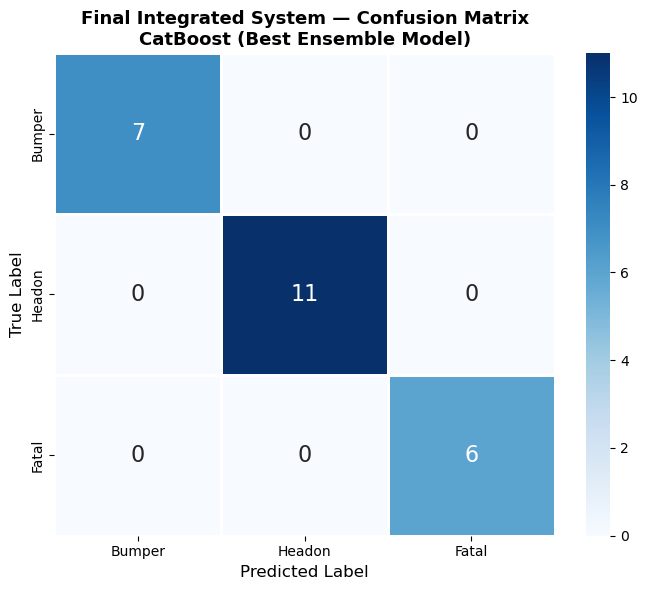


=== Final Classification Report ===
              precision    recall  f1-score   support

      Bumper       1.00      1.00      1.00         7
      Headon       1.00      1.00      1.00        11
       Fatal       1.00      1.00      1.00         6

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



In [70]:
#Final Confusion Matrix

cm_final = confusion_matrix(y_test, y_pred_cat)
class_labels = ['Bumper', 'Headon', 'Fatal']

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=2, linecolor='white', annot_kws={'size': 16})

ax.set_title('Final Integrated System — Confusion Matrix\nCatBoost (Best Ensemble Model)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Final Classification Report ===")
print(classification_report(y_test, y_pred_cat, target_names=class_labels))

### 4.1 Exploration Exploitation Trade off Analysis

The Q-learning agent uses an **ε-greedy** strategy, which is the most
widely studied approach to balancing exploration and exploitation:

**Exploration (high ε):** The agent selects random actions, discovering
the effect of Safety Campaigns on Festive-period Highway accidents it may
never have encountered otherwise. Without this, the agent would commit
prematurely to a suboptimal policy — for example, always recommending
Speed Enforcement even where Road Maintenance would yield greater safety gains.

**Exploitation (low ε):** As ε decays below 0.05, the agent begins
consistently executing the greedy policy derived from its Q-table.
This is observable in the convergence plots — reward variance drops
significantly after episode 2,000.

**Limitations of ε-greedy:** In non-stationary environments (e.g., 
the Festive season causing a sudden spike in accident frequency), a
fixed decay schedule may exploit an outdated policy. Alternatives such
as **Upper Confidence Bound (UCB)** or **Thompson Sampling** are more
adaptive and may be preferable for real-time road safety deployment.

---

### 4.2 Practical and Ethical Implications

**Bias in Data:**
The 2017 dataset contains only 120 records, predominantly from Mpumalanga
and Gauteng. This geographic bias means the model will perform poorly for
provinces with fewer observations (e.g., Limpopo, Northern Cape).
Road safety interventions based on this model risk over-resourcing
high-representation provinces while neglecting underserved ones.

**Transparency and Explainability:**
CatBoost and XGBoost are black-box models. Traffic authorities must be
able to justify enforcement decisions to the public. SHAP (SHapley
Additive exPlanations) values should accompany all model predictions
to explain why a Fatal Accident label was assigned.

**Accountability in Automated Decisions:**
The RL agent's intervention recommendations must remain **advisory**,
not autonomous. Human traffic officials should retain final authority.
Fully automated resource deployment risks exacerbating inequality
if the underlying data contains historical policing biases.

**POPIA Compliance (South Africa):**
The Protection of Personal Information Act (POPIA) requires that any
accident data containing personally identifiable information (street
addresses, licence plate numbers) be anonymised before model training.
The dataset used here contains `Street Name` and `City` fields which
should be generalised or removed in a production deployment.

**Recommendations:**
- Expand the dataset to include all 9 provinces with proportional sampling
- Integrate SHAP explanations into all model outputs
- Implement human-in-the-loop validation before deploying RL interventions
- Conduct quarterly model retraining to detect distribution shift
- Engage community stakeholders in reward function design for the MDP

In [74]:
# FINAL SUMMARY Dashbord

print("=" * 60)
print("  MACHINE LEARNING 700 — COMPONENT A")
print("  FINAL RESULTS SUMMARY")
print("=" * 60)

print("\n── 1. Dataset ──")
print(f"   Records         : {df.shape[0]}")
print(f"   Features used   : {X.shape[1]}")
print(f"   Target classes  : Bumper (0), Headon (1), Fatal (2)")

print("\n── 2. Ensemble Model Performance ──")
print(results.to_string())

best_model_name = results['F1-Score'].idxmax()
best_f1         = results.loc[best_model_name, 'F1-Score']
print(f"\n   Best model: {best_model_name} (F1={best_f1})")

print("\n── 3. Q-Learning Agent ──")
print(f"   MDP States       : {env.N_STATES}")
print(f"   MDP Actions      : {env.N_ACTIONS}")
print(f"   Episodes trained : {N_EPISODES}")
print(f"   Final ε          : {agent.epsilon:.4f}")
print(f"   Avg reward (last 500 eps): {np.mean(episode_rewards[-500:]):.2f}")

print("\n── 4. Policy Summary (sample) ──")
sample_policy = eval_df[['Severity','Location','Optimal Action']].head(9)
print(sample_policy.to_string(index=False))

print("\n── 5. Saved Figures ──")
for fig_name in ['eda_overview.png','outlier_boxplots.png','correlation_heatmap.png',
                 'model_comparison.png','confusion_matrices.png','feature_importance.png',
                 'cv_variance.png','rl_convergence.png','policy_heatmap.png',
                 'final_confusion_matrix.png']:
    print(f"    {fig_name}")

print("=" * 60)

  MACHINE LEARNING 700 — COMPONENT A
  FINAL RESULTS SUMMARY

── 1. Dataset ──
   Records         : 120
   Features used   : 12
   Target classes  : Bumper (0), Headon (1), Fatal (2)

── 2. Ensemble Model Performance ──
               Accuracy  Precision  Recall  F1-Score
Model                                               
Random Forest       1.0        1.0     1.0       1.0
XGBoost             1.0        1.0     1.0       1.0
CatBoost            1.0        1.0     1.0       1.0

   Best model: Random Forest (F1=1.0)

── 3. Q-Learning Agent ──
   MDP States       : 36
   MDP Actions      : 4
   Episodes trained : 5000
   Final ε          : 0.0100
   Avg reward (last 500 eps): -232.03

── 4. Policy Summary (sample) ──
       Severity    Location                 Optimal Action
Bumper Accident Residential Speed Enforcement (Roadblocks)
Bumper Accident Residential                     Do Nothing
Bumper Accident Residential Speed Enforcement (Roadblocks)
Bumper Accident Residential Speed En